In [1]:
!pip install torcheval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 14.4 MB/s eta 0:00:00


In [2]:
from transformers import AutoTokenizer, AutoModel
import torch
from torch import tensor, nn
import torch.nn.functional as F
from torcheval.metrics import BinaryAccuracy

import sys
sys.path.append('/content')
from miniai.training import *
from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

## Load data

In [4]:
import requests

In [5]:
query_url = "https://rest.uniprot.org/uniprotkb/stream?compressed=true&fields=accession%2Csequence%2Ccc_subcellular_location&format=tsv&query=%28%28organism_id%3A9606%29+AND+%28reviewed%3Atrue%29+AND+%28length%3A%5B80+TO+500%5D%29%29"

In [6]:
uniprot_req = requests.get(query_url)

In [7]:
from io import BytesIO
import pandas as pd

uniprot_tab = BytesIO(uniprot_req.content)

df = pd.read_csv(uniprot_tab, compression='gzip', sep='\t')
df.head()

,Entry,Sequence,Subcellular location [CC]
0,A0A0K2S4Q6,MTQRAGAAMLPSALLLLCVPGCLTVSGPSTVMGAVGESLSVQCRYE...,SUBCELLULAR LOCATION: [Isoform 1]: Membrane {E...
1,A0AVI4,MDSPEVTFTLAYLVFAVCFVFTPNEFHAAGLTVQNLLSGWLGSEDA...,SUBCELLULAR LOCATION: Endoplasmic reticulum me...
2,A0JLT2,MENFTALFGAQADPPPPPTALGFGPGKPPPPPPPPAGGGPGTAPPP...,SUBCELLULAR LOCATION: Nucleus {ECO:0000305}.
3,A0M8Q6,GQPKAAPSVTLFPPSSEELQANKATLVCLVSDFNPGAVTVAWKADG...,SUBCELLULAR LOCATION: Secreted {ECO:0000303|Pu...
4,A0PJY2,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,SUBCELLULAR LOCATION: Nucleus {ECO:0000269|Pub...


In [8]:
len(df), len(df.dropna())

(11980, 9885)

In [9]:
df = df.dropna()

In [10]:
len(df['Subcellular location [CC]'].unique())

6325

In [11]:
nucleus = df['Subcellular location [CC]'].str.contains('Nucleus')
membrane = df['Subcellular location [CC]'].str.contains('Membrane') | df['Subcellular location [CC]'].str.contains('Cell membrane')

In [12]:
nuclear_df = df[nucleus & ~membrane]
nuclear_df

,Entry,Sequence,Subcellular location [CC]
2,A0JLT2,MENFTALFGAQADPPPPPTALGFGPGKPPPPPPPPAGGGPGTAPPP...,SUBCELLULAR LOCATION: Nucleus {ECO:0000305}.
4,A0PJY2,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,SUBCELLULAR LOCATION: Nucleus {ECO:0000269|Pub...
5,A0PK00,MSGQLERCEREWHELEGEFQELQETHRIYKQKLEELAALQTLCSSS...,SUBCELLULAR LOCATION: Nucleus inner membrane {...
8,A1A519,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,SUBCELLULAR LOCATION: Nucleus {ECO:0000269|Pub...
9,A1E959,MKIIILLGFLGATLSAPLIPQRLMSASNSNELLLNLNNGQLLPLQL...,SUBCELLULAR LOCATION: Secreted {ECO:0000250|Un...
...,...,...,...
11396,Q7Z5D8,MHRARWLTPVIPALWEAEAGRSRGQEIETILANKKQSAMPWDQDPE...,SUBCELLULAR LOCATION: Nucleus {ECO:0000255|PRO...
11569,Q969E4,MEKPYNKNEGNLENEGKPEDEVEPDDEGKSDEEEKPDVEGKTECEG...,SUBCELLULAR LOCATION: Nucleus {ECO:0000305}.
11580,Q96D70,MVALENPECGPEAAEGTPGGRRLLPLPSCLPALASSQVKRLSASRR...,SUBCELLULAR LOCATION: Nucleus {ECO:0000305}.
11622,Q96QU4,MGKGNEDPDLHCSSIQCSTDQPPFQQISFTEKGSDEKKPFKEKGKT...,SUBCELLULAR LOCATION: Nucleus {ECO:0000250}.


In [13]:
membrane_df = df[~nucleus & membrane]
membrane_df

,Entry,Sequence,Subcellular location [CC]
0,A0A0K2S4Q6,MTQRAGAAMLPSALLLLCVPGCLTVSGPSTVMGAVGESLSVQCRYE...,SUBCELLULAR LOCATION: [Isoform 1]: Membrane {E...
3,A0M8Q6,GQPKAAPSVTLFPPSSEELQANKATLVCLVSDFNPGAVTVAWKADG...,SUBCELLULAR LOCATION: Secreted {ECO:0000303|Pu...
7,A1A4Y4,MEAMNVEKASADGNLPEVISNIKETLKIVSRTPVNITMAGDSGNGM...,SUBCELLULAR LOCATION: Golgi apparatus membrane...
10,A1KXE4,MNPVYSPGSSGVPYANAKGIGYPAGFPMGYAAAAPAYSPNMYPGAN...,"SUBCELLULAR LOCATION: Cytoplasm, perinuclear r..."
16,A2IDD5,MEHAATTGPRPGPPSRRVENVVLRAKDWLPGAPGGTAVWATSLEAE...,"SUBCELLULAR LOCATION: Cytoplasm, cytoskeleton,..."
...,...,...,...
11901,Q86UQ5,MQSDIYHPGHSFPSWVLCWVHSCGHEGHLRETAEIRKTHQNGDLQI...,SUBCELLULAR LOCATION: Membrane {ECO:0000305}; ...
11924,Q8N8V8,MLLKVRRASLKPPATPHQGAFRAGNVIGQLIYLLTWSLFTAWLRPP...,SUBCELLULAR LOCATION: Membrane {ECO:0000305}; ...
11960,Q96N68,MQGQGALKESHIHLPTEQPEASLVLQGQLAESSALGPKGALRPQAQ...,SUBCELLULAR LOCATION: Membrane {ECO:0000305}; ...
11968,Q9H0A3,MMNNTDFLMLNNPWNKLCLVSMDFCFPLDFVSNLFWIFASKFIIVT...,SUBCELLULAR LOCATION: Membrane {ECO:0000255}; ...


In [14]:
nuc_seq = nuclear_df['Sequence'].to_list()
nuc_labels = [0 for seq in nuc_seq]

In [15]:
mem_seq = membrane_df['Sequence'].to_list()
mem_labels = [1 for seq in mem_seq]

In [16]:
seqs = nuc_seq + mem_seq
labels = nuc_labels + mem_labels

In [17]:
len(seqs) == len(labels)

True

## Tokenize sequences

In [18]:
model_checkpoint = "facebook/esm2_t12_35M_UR50D"

In [19]:
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, return_tensors='pt')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [20]:
tokenizer(seqs[0])

{'input_ids': [0, 20, 9, 17, 18, 11, 5, 4, 18, 6, 5, 16, 5, 13, 14, 14, 14, 14, 14, 11, 5, 4, 6, 18, 6, 14, 6, 15, 14, 14, 14, 14, 14, 14, 14, 14, 5, 6, 6, 6, 14, 6, 11, 5, 14, 14, 14, 11, 5, 5, 11, 5, 14, 14, 6, 5, 13, 15, 8, 6, 5, 6, 23, 6, 14, 18, 19, 4, 20, 10, 9, 4, 14, 6, 8, 11, 9, 4, 11, 6, 8, 11, 17, 4, 12, 11, 21, 19, 17, 4, 9, 16, 5, 19, 17, 15, 18, 23, 6, 15, 15, 7, 15, 9, 15, 4, 8, 17, 18, 4, 14, 13, 4, 14, 6, 20, 12, 13, 4, 14, 6, 8, 21, 13, 17, 8, 8, 4, 10, 8, 4, 12, 9, 15, 14, 14, 12, 4, 8, 8, 8, 18, 17, 14, 12, 11, 6, 11, 20, 4, 5, 6, 18, 10, 4, 21, 11, 6, 14, 4, 14, 9, 16, 23, 10, 4, 20, 21, 12, 16, 14, 14, 15, 15, 15, 17, 15, 21, 15, 21, 15, 16, 8, 10, 11, 16, 13, 14, 7, 14, 14, 9, 11, 14, 8, 13, 8, 13, 21, 15, 15, 15, 15, 15, 15, 15, 9, 9, 13, 14, 13, 10, 15, 10, 15, 15, 15, 9, 15, 15, 15, 15, 15, 17, 10, 21, 8, 14, 13, 21, 14, 6, 20, 6, 8, 8, 16, 5, 8, 8, 8, 8, 8, 4, 10, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [21]:
model = AutoModel.from_pretrained(model_checkpoint).to(DEVICE)

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
model

EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 480, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-11): 12 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=480, out_features=480, bias=True)
            (key): Linear(in_features=480, out_features=480, bias=True)
            (value): Linear(in_features=480, out_features=480, bias=True)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=480, out_features=480, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((480,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
          (dense): Linear(in_features=480, out_features=1920, bias=True)
        )
        (output): EsmOutput(
      

In [23]:
def embed_seqs(seq):
  tokens = tokenizer(seq, return_tensors='pt').to(DEVICE)
  with torch.no_grad():
    output = model(**tokens)
  return output.last_hidden_state[:,0,:].cpu().squeeze()

In [24]:
from tqdm import tqdm

seq_emb = []

for seq in tqdm(seqs):
  seq_emb.append(embed_seqs(seq))

100%|██████████| 5772/5772 [01:43<00:00, 55.78it/s]


In [25]:
len(seq_emb), seq_emb[0].shape

(5772, torch.Size([480]))

## Data splits

In [26]:
from sklearn.model_selection import train_test_split

trainval_seqs, test_seqs, trainval_labels, test_labels = train_test_split(seq_emb, labels, test_size=0.2, shuffle=True)

In [27]:
len(trainval_labels), len(test_labels)

(4617, 1155)

In [28]:
trainval_labels.count(0), trainval_labels.count(1), test_labels.count(0), test_labels.count(1)

(2224, 2393, 581, 574)

In [29]:
train_seqs, val_seqs, train_labels, val_labels = train_test_split(trainval_seqs, trainval_labels, test_size=0.1, shuffle=True)

In [30]:
len(train_seqs), len(val_seqs)

(4155, 462)

In [31]:
train_labels.count(0), train_labels.count(1)

(2002, 2153)

## Creating DataLoaders

In [32]:
class ProteinDataset(Dataset):
    def __init__(self, x, y):
      super().__init__(x,y)

    def __getitem__(self, i):
        return self.x[i], tensor(self.y[i]).unsqueeze(0).float()

In [33]:
bs=256

In [34]:
train_ds = ProteinDataset(train_seqs, train_labels)
train_ds[0]

(tensor([-1.6214e-01, -2.8833e-01, -1.8304e-02,  1.6804e-01,  4.3170e-01,
         -9.6348e-02, -3.1001e-01,  4.8644e-02,  4.7308e-02,  7.4851e-02,
          1.7395e-01, -1.8046e-01,  1.1911e-01, -4.8571e-02,  2.2208e-01,
         -5.7769e-03,  1.7508e-01, -2.3670e-01, -1.5753e-01,  1.4326e-01,
         -5.9043e-02,  1.0806e-01, -2.2420e-01,  4.6457e-01,  3.4247e-01,
          1.9970e-01,  1.5720e-01, -8.6332e-02, -1.5435e-01,  4.5682e-03,
          1.5004e-01, -3.4932e-01, -4.5211e-01,  2.2213e-01,  4.3401e-02,
          1.5532e-01, -9.3224e-02,  4.4235e-01,  3.2498e-01, -1.4283e-01,
          1.3892e-01,  8.6756e-02,  9.4211e-02, -6.9014e-01, -3.1294e-02,
         -4.1325e-02,  5.0531e+00,  1.3033e-01, -1.9387e-01,  2.1512e-01,
         -3.2978e-01, -1.9904e-01, -1.7386e-01, -7.7927e-02,  5.6524e-01,
          3.9242e-03, -1.2920e-01, -5.4817e-02, -1.1219e-01, -6.6655e-02,
         -3.7071e-01,  2.6380e-01,  1.7009e-01, -4.9719e-02, -4.7381e-02,
          2.0106e-01, -3.7429e-02,  4.

In [35]:
valid_ds = ProteinDataset(val_seqs, val_labels)
valid_ds[0]

(tensor([-1.3828e-01, -1.9696e-01,  1.0263e-01,  1.9260e-01,  2.9536e-01,
         -6.1068e-03, -4.0231e-01, -3.4041e-02,  1.4022e-01,  9.0374e-02,
          1.1799e-01, -1.6816e-01,  1.8928e-01,  2.7871e-02,  2.9191e-01,
         -2.2116e-01,  2.5154e-01, -7.6546e-02, -1.3531e-01,  4.3475e-01,
          1.5289e-02,  2.4011e-01, -2.3758e-01,  4.5130e-01,  1.6424e-01,
         -6.3180e-02,  9.5025e-02,  1.7242e-02, -3.3285e-01, -1.2151e-01,
          2.9932e-02, -1.7886e-01, -5.2080e-01,  2.3258e-01, -8.8026e-02,
          2.2777e-01, -5.6988e-02,  5.0023e-01,  3.1125e-01, -4.4458e-02,
          1.4946e-01,  9.0013e-02,  1.7145e-01, -6.9178e-01, -5.3573e-02,
         -1.7991e-01,  5.0657e+00,  1.4607e-01, -2.6854e-01,  2.4073e-01,
         -1.5228e-01, -1.9929e-01, -3.1372e-01, -1.0742e-01,  3.8023e-01,
         -1.1846e-02, -6.8737e-02, -1.5719e-02, -1.8204e-01, -2.0790e-01,
         -4.1758e-01,  3.8109e-01,  2.0822e-01,  1.1382e-02, -1.3269e-01,
          1.3356e-01, -1.8980e-01,  5.

In [36]:
from torch.utils.data import DataLoader

dls = DataLoaders(*get_dls(train_ds, valid_ds, bs))

In [37]:
next(iter(dls.train))[1].shape

torch.Size([256, 1])

## Creating the classification model

In [38]:
mlp = nn.Sequential(
    nn.Linear(480, 256),
    nn.ReLU(),
    nn.LayerNorm(256),

    nn.Linear(256, 1)
)

In [ ]:
# class BCETrainLearner(TrainLearner):
#   def get_loss(self):
#     preds = self.preds.view(-1)         # [batch_size]
#     targets = self.batch[1].view(-1).float()  # [batch_size]
#     self.loss = self.loss_func(preds, targets)

In [39]:
class BCEMetricsCB(MetricsCB):
  def after_batch(self,learn):
    x,y,*_ = to_cpu(learn.batch)
    # convert logits --> probs
    probs = torch.sigmoid(to_cpu(learn.preds.view(-1)))
    # threshold: convert probs --> hard predictions
    preds = (probs > 0.5).long()
    # integer labels instead of float
    y = y.view(-1).long()
    # update all metrics
    for m in self.metrics.values():
        m.update(preds,y)
    # update loss
    self.loss.update(to_cpu(learn.loss.detach()), weight=len(x))

In [40]:
epochs=10
lr=1e-2
cbs = [DeviceCB(), ProgressCB(plot=True), BCEMetricsCB(accuracy=BinaryAccuracy())]
learn = TrainLearner(mlp, dls, loss_func=nn.BCEWithLogitsLoss(), lr=lr, cbs=cbs, opt_func=torch.optim.Adam)

accuracy,loss,epoch,train
0.520,1.047,0,train
0.481,0.694,0,eval
0.578,0.652,1,train
0.688,0.591,1,eval
0.785,0.505,2,train
0.799,0.435,2,eval
0.851,0.371,3,train
0.848,0.351,3,eval
0.884,0.293,4,train
0.881,0.304,4,eval


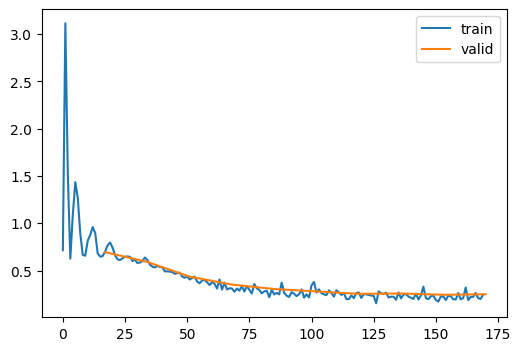

In [41]:
learn.fit(epochs)

### Weight initializations

In [42]:
def init_weights(m):
  if isinstance(m, nn.Linear):
    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    if m.bias is not None:
      nn.init.zeros_(m.bias)

In [43]:
learn = TrainLearner(mlp.apply(init_weights), dls, loss_func=nn.BCEWithLogitsLoss(), lr=lr,
                     cbs=cbs, opt_func=torch.optim.Adam)

accuracy,loss,epoch,train
0.530,1.498,0,train
0.519,0.777,0,eval
0.582,0.643,1,train
0.788,0.580,1,eval
0.822,0.536,2,train
0.805,0.490,2,eval
0.846,0.430,3,train
0.827,0.393,3,eval
0.872,0.336,4,train
0.859,0.326,4,eval


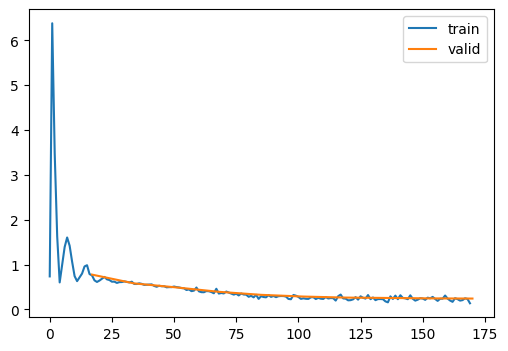

In [44]:
learn.fit(epochs)

### Input normalization

In [45]:
xb,yb = next(iter(dls.train))
xb

tensor([[-2.1510e-01, -2.7742e-01,  5.6156e-02,  ..., -4.0091e-01,
         -4.0664e-04,  6.8747e-02],
        [-4.7814e-02, -1.9373e-01, -1.0515e-02,  ..., -6.0878e-01,
         -2.8316e-02,  4.6076e-02],
        [-1.1120e-01, -3.0955e-01, -5.4425e-04,  ..., -6.5243e-01,
         -1.2359e-01,  9.8455e-03],
        ...,
        [-2.5588e-01, -3.0613e-01, -6.3900e-02,  ..., -6.0374e-01,
         -1.9244e-01, -1.4739e-01],
        [-6.0736e-02, -2.5199e-01,  5.0638e-02,  ..., -5.8422e-01,
         -1.8916e-01,  1.0334e-01],
        [-7.8544e-02, -9.5731e-02,  1.0686e-02,  ..., -5.3345e-01,
         -7.1119e-03,  1.7568e-03]])

In [46]:
xmean, xstd = xb.mean(), xb.std()
xmean, xstd

(tensor(0.0061), tensor(0.3610))

In [47]:
def _norm(b):
  return (b[0]-xmean)/xstd, b[1]

In [48]:
norm = BatchTransformCB(_norm)

In [49]:
learn = TrainLearner(mlp.apply(init_weights), dls, loss_func=nn.BCEWithLogitsLoss(), lr=lr, cbs=cbs+[norm], opt_func=torch.optim.Adam)

accuracy,loss,epoch,train
0.512,1.461,0,train
0.519,0.764,0,eval
0.605,0.635,1,train
0.539,0.598,1,eval
0.774,0.530,2,train
0.790,0.497,2,eval
0.843,0.439,3,train
0.829,0.419,3,eval
0.860,0.362,4,train
0.857,0.349,4,eval


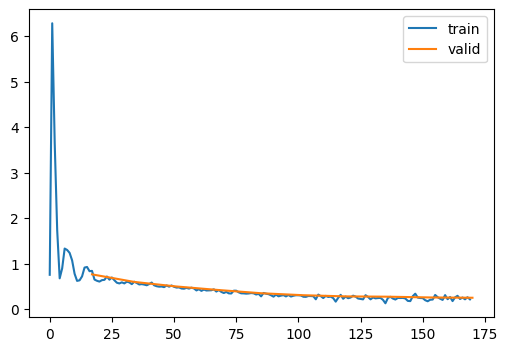

In [50]:
learn.fit(epochs)

### LR scheduler

In [ ]:
from torch.optim import lr_scheduler
from functools import partial

In [ ]:
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.CosineAnnealingLR, T_max=tmax)
lr_sched = BatchSchedCB(sched)

In [ ]:
learn = TrainLearner(mlp.apply(init_weights), dls, loss_func=nn.BCEWithLogitsLoss(), lr=lr, cbs=cbs+[norm, lr_sched], opt_func=torch.optim.Adam)

accuracy,loss,epoch,train
0.505,1.463,0,train
0.500,0.896,0,eval
0.577,0.686,1,train
0.504,0.641,1,eval
0.697,0.582,2,train
0.797,0.550,2,eval
0.830,0.490,3,train
0.794,0.478,3,eval
0.841,0.410,4,train
0.823,0.418,4,eval


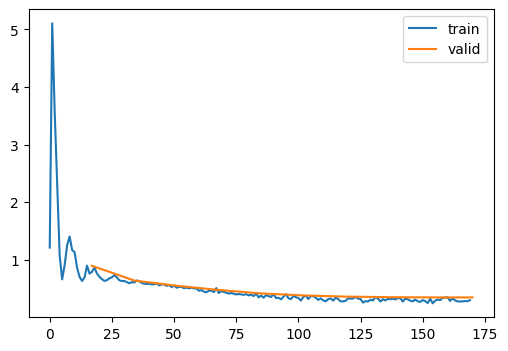

In [ ]:
learn.fit(10)

## Test the final model

In [51]:
len(test_seqs), len(test_labels)

(1155, 1155)

In [52]:
torch.stack(test_seqs).shape

torch.Size([1155, 480])

In [53]:
with torch.no_grad(): logits = learn.model(torch.stack(test_seqs).to(DEVICE))

In [54]:
logits.shape

torch.Size([1155, 1])

In [55]:
logits[:5]

tensor([[ 0.4754],
        [ 1.7281],
        [-2.0822],
        [-2.3252],
        [-3.9117]], device='cuda:0')

In [56]:
probs = torch.sigmoid(logits)

In [57]:
preds = (probs > 0.5).float().squeeze()

In [58]:
targets = torch.tensor(test_labels).float()

In [59]:
(preds.cpu().squeeze() == targets).float().mean(0)

tensor(0.9264)

## Evaluate the model

In [61]:
import numpy as np

c = 2
conf_mat = np.zeros((c,c))

for i in range(c):
  idx = torch.argwhere(targets == i)
  for j in range(c):
    conf_mat[i, j] += (preds.cpu()[idx] == j).sum()

In [62]:
conf_mat

array([[569.,  12.],
       [ 73., 501.]])

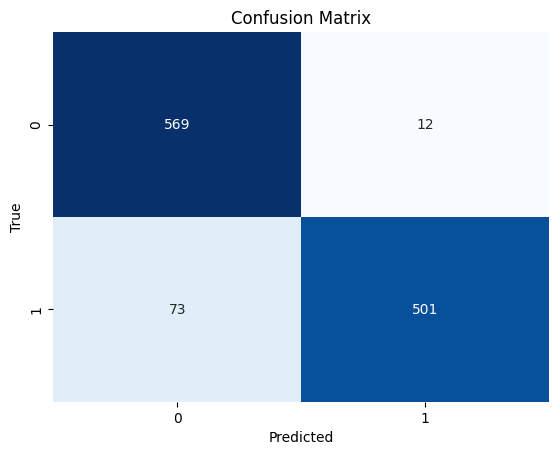

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(conf_mat, annot=True, fmt='g', cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [64]:
per_class_acc = conf_mat.diagonal() / conf_mat.sum(axis=1)

for i, acc in enumerate(per_class_acc):
    print(f"Class {i} accuracy: {acc:.3f}")

Class 0 accuracy: 0.979
Class 1 accuracy: 0.873


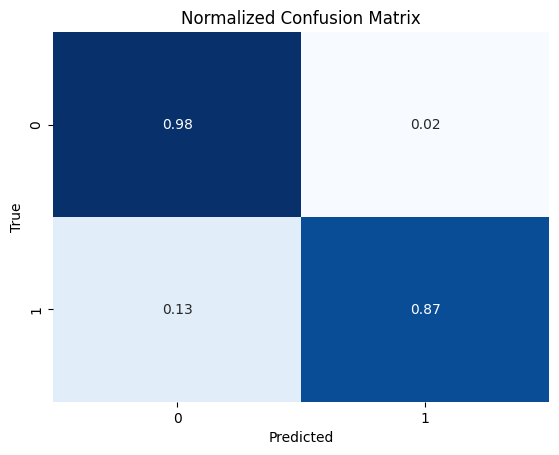

In [65]:
cm_norm = conf_mat / conf_mat.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

In [68]:
from sklearn.metrics import classification_report

print(classification_report(targets, preds.cpu()))

              precision    recall  f1-score   support

         0.0       0.89      0.98      0.93       581
         1.0       0.98      0.87      0.92       574

    accuracy                           0.93      1155
   macro avg       0.93      0.93      0.93      1155
weighted avg       0.93      0.93      0.93      1155

